# Friedkin-Johnsen Bias Variants 

In [21]:
import json
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [22]:
import hashlib

ROOT = Path('/home/sammli/llm-network')
CLEAN = ROOT / 'modeling' / 'cleaned_data'
RUN_DIRS = sorted([p for p in CLEAN.glob('run_*') if p.is_dir()])
assert RUN_DIRS, f'No run_* folders in {CLEAN}'
RECENT_RUNS = RUN_DIRS[-3:]
assert len(RECENT_RUNS) == 3, f'Expected at least 3 runs, found {len(RUN_DIRS)}'
LATEST_RUN = RECENT_RUNS[-1]

PARAMS = {
    'lambda_grid': [0.2, 0.4, 0.6, 0.8],
    # Experiment 1: b_i = clip(beta0 + beta_assigned*(assigned_i-0.5)
    #                          + beta_profile*(profile_i-0.5) + beta_init*(init_i-0.5) + eps_i, 0, 1)
    'beta0_grid': np.linspace(0.2, 0.8, 7).tolist(),
    'beta_assigned_grid': [-1.0, -0.5, 0.0, 0.5, 1.0],
    'beta_profile_grid': [-1.0, -0.5, 0.0, 0.5, 1.0],
    'beta_init_grid': [-1.0, -0.5, 0.0, 0.5, 1.0],
    # Small deterministic noise injection in Experiment 1.
    'exp1_noise_std': 0.01,
    'noise_seed': 23,
    # Experiment 2: additive upward lift delta added to each agent's initial opinion.
    'bias_lift_grid': np.linspace(0.0, 0.35, 15).tolist(),
    # Train/plot windows focused on early dynamics including initialization and approach to convergence.
    'exp1_eval_horizon': 20,
    'exp1_plot_horizon': 20,
    'exp2_eval_horizon': 20,
    'exp2_plot_horizon': 20,
}

print('Using recent runs for fitting (first 20 slices for both experiments):')
for r in RECENT_RUNS:
    print(' ', r.name)
print('Plotting only latest run:', LATEST_RUN.name)


def load_json(path: Path):
    with path.open('r', encoding='utf-8') as f:
        return json.load(f)


def load_jsonl(path: Path):
    rows = []
    if not path.exists():
        return rows
    with path.open('r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


def numeric_agent_key(agent_id: str):
    if isinstance(agent_id, str) and agent_id.startswith('agent_'):
        tail = agent_id.split('_')[-1]
        if tail.isdigit():
            return int(tail)
    return 10**9


def parse_agent_id(v):
    if isinstance(v, str) and v.startswith('agent_'):
        return v
    if isinstance(v, int):
        return f'agent_{v}'
    return None


def get_graph_adjacency(graph):
    if isinstance(graph, dict) and 'edges' in graph:
        adj = defaultdict(list)
        for src, dst in graph.get('edges', []):
            s = parse_agent_id(src)
            d = parse_agent_id(dst)
            if s and d:
                adj[s].append(d)
        return dict(adj)
    if isinstance(graph, dict):
        return {k: list(v) for k, v in graph.items() if isinstance(v, list)}
    return {}


def to_unit_interval(x):
    x = np.asarray(x, dtype=float)
    return np.clip((x + 1.0) / 2.0, 0.0, 1.0)


def from_unit_interval(z):
    z = np.asarray(z, dtype=float)
    return np.clip(2.0 * z - 1.0, -1.0, 1.0)


def deterministic_noise(run_name: str, agent_id: str, std: float, seed: int):
    if std <= 0:
        return 0.0
    token = f"{run_name}|{agent_id}|{seed}".encode('utf-8')
    h = hashlib.sha256(token).hexdigest()
    local_seed = int(h[:16], 16) % (2**32 - 1)
    rng = np.random.default_rng(local_seed)
    return float(rng.normal(0.0, std))


def build_slice_observations(run_dir: Path):
    profile_by_agent_slice = defaultdict(lambda: defaultdict(list))
    first_self_posts = {}

    per_agent_dir = run_dir / 'per_agent'
    if not per_agent_dir.exists():
        return {}, {}, 0

    max_time_slice = 0
    for fp in sorted(per_agent_dir.glob('agent_*.jsonl')):
        agent_id = fp.stem
        for row in load_jsonl(fp):
            # Profile observation (target): topology profile ss by time slice.
            slice_idx = row.get('matched_topology_snapshot_time_slice', row.get('message_time_slice'))
            topo = row.get('topology_profile_for_agent', {}) or {}
            obs_ss = topo.get('ss', None)
            if slice_idx is not None and obs_ss is not None:
                slice_idx = int(slice_idx)
                profile_by_agent_slice[agent_id][slice_idx].append(float(obs_ss))
                max_time_slice = max(max_time_slice, slice_idx)

            # Initialization proxy from first self-post expression.
            if not row.get('is_self_influence'):
                continue
            msg_slice = row.get('message_time_slice', None)
            pub = (row.get('published') or {}).get('stance_score', None)
            msg_index = row.get('message_index', None)
            if msg_slice is None or pub is None or msg_index is None:
                continue

            candidate = {
                'time_slice': int(msg_slice),
                'stance_score': float(pub),
                'message_index': int(msg_index),
            }
            existing = first_self_posts.get(agent_id)
            if existing is None or (candidate['time_slice'], candidate['message_index']) < (existing['time_slice'], existing['message_index']):
                first_self_posts[agent_id] = candidate

    profile_by_agent_slice = {
        agent: {ts: float(np.mean(vals)) for ts, vals in ts_map.items()}
        for agent, ts_map in profile_by_agent_slice.items()
    }

    return profile_by_agent_slice, first_self_posts, int(max_time_slice)


def load_run_data(run_dir: Path):
    graph = get_graph_adjacency(load_json(run_dir / 'connection_graph.json'))
    profile_by_agent_slice, first_self_posts, max_time_slice = build_slice_observations(run_dir)

    static_init_path = run_dir / 'static_init.json'
    static_init = load_json(static_init_path) if static_init_path.exists() else {}
    stance_weights = static_init.get('stance_weights', {}) or {}

    agent_ids = set(graph.keys())
    for src, dsts in graph.items():
        agent_ids.add(src)
        agent_ids.update(dsts)
    agent_ids.update(profile_by_agent_slice.keys())
    agent_ids.update(first_self_posts.keys())
    agent_ids.update([parse_agent_id(a) for a in stance_weights.keys() if parse_agent_id(a) is not None])
    agent_ids = sorted(agent_ids, key=numeric_agent_key)

    # Assigned initialization on [-1, 1] from static_init (if present).
    assigned_init_unit = {}
    for a in agent_ids:
        w = stance_weights.get(a, None)
        if w is None:
            assigned_init_unit[a] = np.nan
        else:
            assigned_init_unit[a] = float(to_unit_interval(float(w)))

    return {
        'run_name': run_dir.name,
        'graph': graph,
        'agent_ids': agent_ids,
        'profile_by_agent_slice': profile_by_agent_slice,
        'first_self_posts': first_self_posts,
        'assigned_init_unit': assigned_init_unit,
        'max_time_slice': int(max_time_slice),
    }


def build_predecessors(graph, agent_ids):
    preds = {a: [] for a in agent_ids}
    for src, dsts in graph.items():
        for dst in dsts:
            if dst in preds:
                preds[dst].append(src)
    return preds


def build_W_for_fj(preds, agent_ids):
    n = len(agent_ids)
    idx = {a: i for i, a in enumerate(agent_ids)}
    W = np.zeros((n, n), dtype=float)
    for dst in agent_ids:
        j = idx[dst]
        p = preds.get(dst, [])
        if p:
            w = 1.0 / len(p)
            for src in p:
                if src in idx:
                    W[j, idx[src]] = w
        else:
            W[j, j] = 1.0
    return W, idx


def initial_signals(data):
    assigned = {}
    profile_init = {}
    init_post = {}
    base_x0 = {}

    for a in data['agent_ids']:
        # Assigned init from static init if available.
        ai = data['assigned_init_unit'].get(a, np.nan)
        assigned[a] = float(ai) if np.isfinite(float(ai)) else np.nan

        # Profile-based initial observation (slice 0 if possible).
        profile_map = data['profile_by_agent_slice'].get(a, {})
        if 0 in profile_map:
            p0_ss = float(profile_map[0])
        elif profile_map:
            first_slice = min(profile_map)
            p0_ss = float(profile_map[first_slice])
        elif np.isfinite(float(ai)):
            p0_ss = float(from_unit_interval(ai))
        else:
            p0_ss = 0.0
        profile_init[a] = float(to_unit_interval(p0_ss))

        # First self-post init if present, else fallback to profile init.
        fs = data['first_self_posts'].get(a)
        if fs is not None:
            init_ss = float(fs['stance_score'])
            init_post[a] = float(to_unit_interval(init_ss))
        else:
            init_post[a] = float(profile_init[a])

        # Fill missing assigned from profile init for stable deterministic initialization.
        if not np.isfinite(float(assigned[a])):
            assigned[a] = float(profile_init[a])

        # Existing initial opinion used by global-bias mixture model.
        base_x0[a] = float(np.clip(0.85 * assigned[a] + 0.15 * profile_init[a], 0.0, 1.0))

    return assigned, profile_init, init_post, base_x0


def run_fj_with_x0(data, lam, x0_unit_dict):
    """Experiment 1 dynamics: z(t+1) = lam*x0 + (1-lam)*Wz(t)."""
    agent_ids = data['agent_ids']
    preds = build_predecessors(data['graph'], agent_ids)
    W, idx = build_W_for_fj(preds, agent_ids)

    z0 = np.array([float(x0_unit_dict[a]) for a in agent_ids], dtype=float)
    z = z0.copy()

    records = []
    max_slice = int(data['max_time_slice'])
    for time_slice in range(0, max_slice + 1):
        if time_slice > 0:
            social = W @ z
            z = np.clip(float(lam) * z0 + (1.0 - float(lam)) * social, 0.0, 1.0)

        for a in agent_ids:
            obs_map = data['profile_by_agent_slice'].get(a, {})
            has_obs = time_slice in obs_map
            if has_obs:
                obs_ss = float(obs_map[time_slice])
                obs_unit = float(to_unit_interval(obs_ss))
            else:
                obs_ss = np.nan
                obs_unit = np.nan

            pred_unit = float(z[idx[a]])
            records.append(
                {
                    'run': data['run_name'],
                    'time_slice': int(time_slice),
                    'agent': a,
                    'pred_unit': pred_unit,
                    'obs_unit': obs_unit,
                    'pred_ss': float(from_unit_interval(pred_unit)),
                    'obs_ss': float(obs_ss) if np.isfinite(obs_ss) else np.nan,
                    'has_obs': bool(has_obs),
                }
            )

    return {
        'records': records,
        'z0': {a: float(x0_unit_dict[a]) for a in agent_ids},
        'W': W,
        'idx': idx,
    }


def run_fj_with_global_bias_lift(data, lam_social, bias_lift, base_x0_unit_dict):
    """Experiment 2 dynamics:
    z(0) = clip(x0 + delta, 0, 1),
    z(t+1) = lam_social * W z(t) + (1-lam_social) * clip(x0 + delta, 0, 1),
    where delta is the same upward lift applied to every agent.
    """
    agent_ids = data['agent_ids']
    preds = build_predecessors(data['graph'], agent_ids)
    W, idx = build_W_for_fj(preds, agent_ids)

    x0_base = np.array([float(base_x0_unit_dict[a]) for a in agent_ids], dtype=float)
    bias_lift_value = float(np.clip(float(bias_lift), 0.0, 1.0))
    anchor = np.clip(x0_base + bias_lift_value, 0.0, 1.0)

    # Apply the same upward lift to each agent while preserving relative differences.
    z = anchor.copy()

    records = []
    max_slice = int(data['max_time_slice'])
    for time_slice in range(0, max_slice + 1):
        if time_slice > 0:
            social = W @ z
            z = np.clip(float(lam_social) * social + (1.0 - float(lam_social)) * anchor, 0.0, 1.0)

        for a in agent_ids:
            obs_map = data['profile_by_agent_slice'].get(a, {})
            has_obs = time_slice in obs_map
            if has_obs:
                obs_ss = float(obs_map[time_slice])
                obs_unit = float(to_unit_interval(obs_ss))
            else:
                obs_ss = np.nan
                obs_unit = np.nan

            pred_unit = float(z[idx[a]])
            records.append(
                {
                    'run': data['run_name'],
                    'time_slice': int(time_slice),
                    'agent': a,
                    'pred_unit': pred_unit,
                    'obs_unit': obs_unit,
                    'pred_ss': float(from_unit_interval(pred_unit)),
                    'obs_ss': float(obs_ss) if np.isfinite(obs_ss) else np.nan,
                    'has_obs': bool(has_obs),
                }
            )

    return {
        'records': records,
        'bias_lift_value': float(bias_lift_value),
        'anchor': {a: float(anchor[idx[a]]) for a in agent_ids},
        'x0_base': {a: float(base_x0_unit_dict[a]) for a in agent_ids},
        'W': W,
        'idx': idx,
    }


def evaluate_records(records, horizon=10):
    if not records:
        return {'mae': np.nan, 'rmse': np.nan, 'n_eval': 0}

    df = pd.DataFrame(records)
    df = df[(df['has_obs']) & (df['time_slice'] <= int(horizon))].copy()
    if df.empty:
        return {'mae': np.nan, 'rmse': np.nan, 'n_eval': 0}

    d = (df['pred_unit'] - df['obs_unit']).to_numpy(dtype=float)
    return {
        'mae': float(np.mean(np.abs(d))),
        'rmse': float(np.sqrt(np.mean(d * d))),
        'n_eval': int(len(df)),
    }


def plot_all_agents(df, title, horizon=10):
    d = df[df['time_slice'] <= int(horizon)].copy()
    agent_order = sorted(d['agent'].unique(), key=numeric_agent_key)
    palette = np.array(list(plt.cm.tab20.colors) + list(plt.cm.Set3.colors) + list(plt.cm.Dark2.colors))[:len(agent_order)]

    plt.figure(figsize=(9.6, 5.4))
    for i, agent in enumerate(agent_order):
        dfa = d[d['agent'] == agent].sort_values('time_slice')
        dfa_obs = dfa[dfa['has_obs']].copy()

        base_rgb = np.asarray(palette[i][:3], dtype=float)
        obs_rgb = 0.55 * np.array([0.72, 0.72, 0.72]) + 0.45 * base_rgb

        plt.plot(
            dfa_obs['time_slice'],
            dfa_obs['obs_unit'],
            color=(*obs_rgb, 0.40),
            linewidth=0.8,
            marker='o',
            markersize=1.8,
            solid_capstyle='round',
        )
        plt.plot(
            dfa['time_slice'],
            dfa['pred_unit'],
            color=(*base_rgb, 0.90),
            linewidth=1.35,
            solid_capstyle='round',
        )

    legend_handles = [
        Line2D([0], [0], color=(0.45, 0.45, 0.45, 0.45), linewidth=0.9, marker='o', markersize=3, label='observed slices'),
        Line2D([0], [0], color=(0.2, 0.2, 0.2, 0.95), linewidth=1.5, label='predicted'),
    ]
    plt.title(title)
    plt.xlabel('time slice')
    plt.ylabel('scaled stance score [0,1]')
    plt.ylim(0.0, 1.0)
    plt.xlim(0, max(1, int(horizon)))
    plt.legend(handles=legend_handles, loc='upper right', frameon=False)
    plt.tight_layout()
    plt.show()


RUN_DATA = {r.name: load_run_data(r) for r in RECENT_RUNS}
for rn, rd in RUN_DATA.items():
    n_profile_obs = sum(len(v) for v in rd['profile_by_agent_slice'].values())
    print(rn, 'agents=', len(rd['agent_ids']), 'max_time_slice=', rd['max_time_slice'], 'profile_obs=', n_profile_obs)

Using recent runs for fitting (first 20 slices for both experiments):
  run_20260306-215035
  run_20260307-005112
  run_20260307-175802
Plotting only latest run: run_20260307-175802
run_20260306-215035 agents= 30 max_time_slice= 139 profile_obs= 3086
run_20260307-005112 agents= 30 max_time_slice= 110 profile_obs= 2363
run_20260307-175802 agents= 30 max_time_slice= 37 profile_obs= 1127


## Experiment 1: Agent-specific bias vector b_i

We learn a deterministic per-agent anchor from initialization signals:

$$
b_i = \mathrm{clip}\left(\beta_0 + \beta_a(a_i-0.5) + \beta_p(p_i-0.5) + \beta_i(s_i-0.5) + \epsilon_i,\;0,\;1\right)
$$

where:
- $a_i$ = assigned initial opinion from `static_init` (mapped to $[0,1]$)
- $p_i$ = profile-based initial opinion from early observed profile stance
- $s_i$ = first self-post initialization (mapped to $[0,1]$)
- $\epsilon_i$ = small deterministic noise term (seeded by run+agent)

Then FJ update is:

$$
z_i(t+1)=\lambda\,b_i + (1-\lambda)\,\sum_j W_{ij}z_j(t)
$$

Prediction objective: choose $(\lambda,\beta_0,\beta_a,\beta_p,\beta_i)$ that minimizes weighted RMSE over the **3 runs**, restricted to the **first 20 slices** with true observed profile stances.

,lambda,beta0,beta_assigned,beta_profile,beta_init,rmse,mae,n_eval
0,0.2,0.4,0.0,1.0,1.0,0.109289,0.086128,1547
1,0.4,0.4,0.0,1.0,1.0,0.113653,0.092157,1547
2,0.2,0.5,0.0,1.0,0.5,0.115485,0.098290,1547
3,0.4,0.4,0.0,0.5,1.0,0.116113,0.099722,1547
4,0.4,0.7,0.0,0.5,0.0,0.116146,0.079149,1547
5,0.2,0.5,0.5,1.0,1.0,0.116643,0.091177,1547
6,0.6,0.7,0.0,0.5,0.0,0.116650,0.083829,1547
7,0.4,0.6,0.0,0.5,0.5,0.116874,0.073372,1547
8,0.6,0.4,0.0,0.5,1.0,0.117038,0.097996,1547
9,0.2,0.4,0.0,0.5,1.0,0.117238,0.102108,1547


Best Experiment-1 params: {'lambda': 0.2, 'beta0': 0.4, 'beta_assigned': 0.0, 'beta_profile': 1.0, 'beta_init': 1.0, 'rmse': 0.1092891981767957, 'mae': 0.08612814047719972, 'n_eval': 1547.0}


,agent,assigned_init,profile_init,first_post_init,base_existing_x0,bias_unit,bias_ss
0,agent_1,0.00,0.559203,0.701857,0.083880,0.670002,0.340004
1,agent_2,0.25,0.337898,0.780099,0.263185,0.517490,0.034980
2,agent_3,0.50,0.608507,0.785291,0.516276,0.786727,0.573454
3,agent_4,0.25,0.675690,0.758158,0.313854,0.841531,0.683063
4,agent_5,0.75,0.754219,0.724099,0.750633,0.880822,0.761644
5,agent_6,0.50,0.608507,0.779595,0.516276,0.784770,0.569540
6,agent_7,0.75,0.785259,0.768300,0.755289,0.946136,0.892272
7,agent_8,0.00,0.511727,0.760167,0.076759,0.669667,0.339333
8,agent_9,0.00,0.519884,0.766556,0.077983,0.678153,0.356307
9,agent_10,1.00,0.772923,0.764732,0.965938,0.926066,0.852132


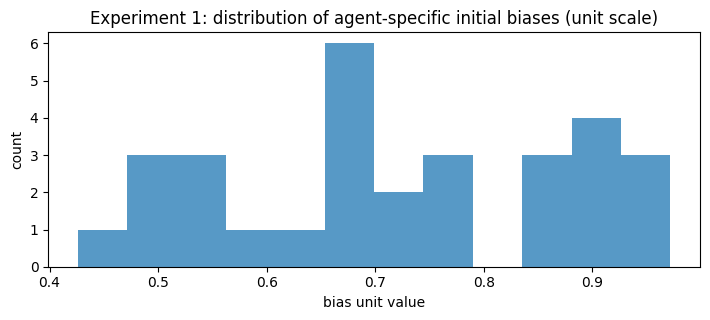

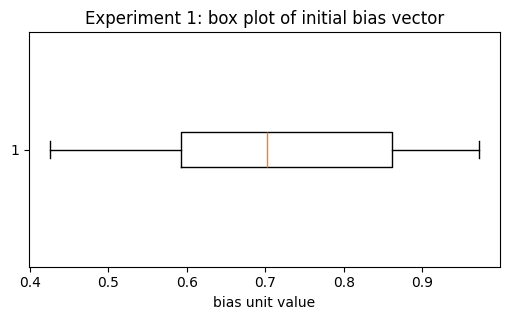

Experiment 1 latest-run metrics (first 20 slices): {'mae': 0.07596753081702254, 'rmse': 0.09225512949972389, 'n_eval': 622}


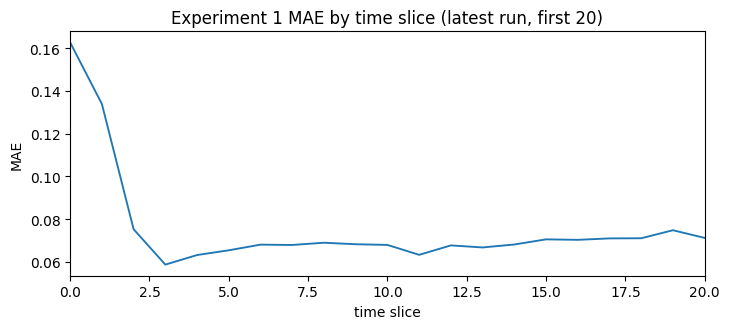

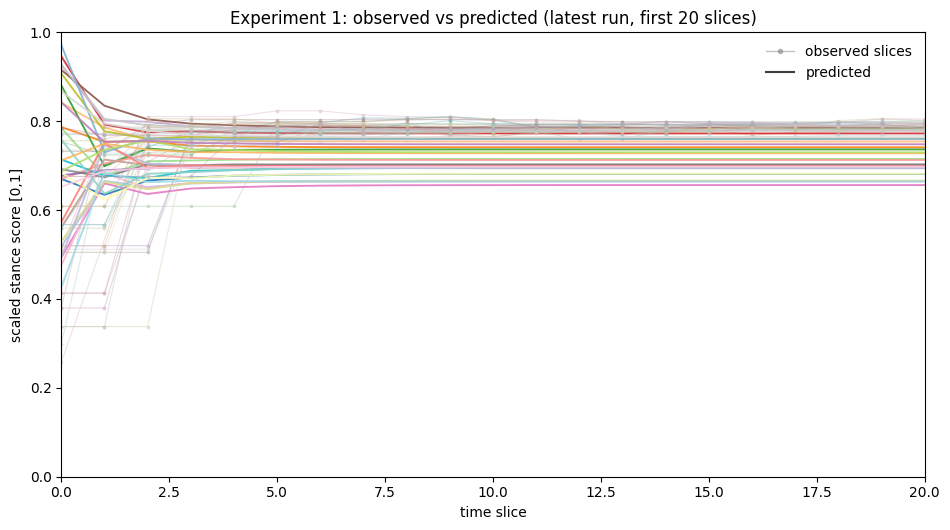

In [23]:
def build_agent_bias_vector(
    run_name,
    assigned_init,
    profile_init,
    init_post,
    beta0,
    beta_assigned,
    beta_profile,
    beta_init,
    noise_std=0.0,
    noise_seed=0,
):
    out = {}
    for a in assigned_init.keys():
        eps_i = deterministic_noise(run_name, a, std=float(noise_std), seed=int(noise_seed))
        bi = (
            beta0
            + beta_assigned * (assigned_init[a] - 0.5)
            + beta_profile * (profile_init[a] - 0.5)
            + beta_init * (init_post[a] - 0.5)
            + eps_i
        )
        out[a] = float(np.clip(bi, 0.0, 1.0))
    return out


rows = []
for lam in PARAMS['lambda_grid']:
    for beta0 in PARAMS['beta0_grid']:
        for b_assigned in PARAMS['beta_assigned_grid']:
            for b_profile in PARAMS['beta_profile_grid']:
                for b_init in PARAMS['beta_init_grid']:
                    run_metrics = []
                    for run_name, data in RUN_DATA.items():
                        assigned_init, profile_init, init_post, base_x0 = initial_signals(data)
                        x0 = build_agent_bias_vector(
                            run_name,
                            assigned_init,
                            profile_init,
                            init_post,
                            beta0,
                            b_assigned,
                            b_profile,
                            b_init,
                            noise_std=PARAMS['exp1_noise_std'],
                            noise_seed=PARAMS['noise_seed'],
                        )
                        out = run_fj_with_x0(data, lam=lam, x0_unit_dict=x0)
                        m = evaluate_records(out['records'], horizon=PARAMS['exp1_eval_horizon'])
                        run_metrics.append(m)

                    n_total = int(sum(m['n_eval'] for m in run_metrics))
                    if n_total == 0:
                        continue
                    w_rmse = float(np.sqrt(np.sum([(m['rmse'] ** 2) * m['n_eval'] for m in run_metrics]) / n_total))
                    w_mae = float(np.sum([m['mae'] * m['n_eval'] for m in run_metrics]) / n_total)
                    rows.append(
                        {
                            'lambda': float(lam),
                            'beta0': float(beta0),
                            'beta_assigned': float(b_assigned),
                            'beta_profile': float(b_profile),
                            'beta_init': float(b_init),
                            'rmse': w_rmse,
                            'mae': w_mae,
                            'n_eval': n_total,
                        }
                    )

exp1_res = pd.DataFrame(rows).sort_values(['rmse', 'mae']).reset_index(drop=True)
display(exp1_res.head(10))
best1 = exp1_res.iloc[0].to_dict()
print('Best Experiment-1 params:', best1)

latest_data = RUN_DATA[LATEST_RUN.name]
assigned_latest, profile_latest, init_latest, base_latest = initial_signals(latest_data)
x0_best_latest = build_agent_bias_vector(
    latest_data['run_name'],
    assigned_latest,
    profile_latest,
    init_latest,
    best1['beta0'],
    best1['beta_assigned'],
    best1['beta_profile'],
    best1['beta_init'],
    noise_std=PARAMS['exp1_noise_std'],
    noise_seed=PARAMS['noise_seed'],
)

bias_df = (
    pd.DataFrame(
        {
            'agent': list(x0_best_latest.keys()),
            'assigned_init': [assigned_latest[a] for a in x0_best_latest.keys()],
            'profile_init': [profile_latest[a] for a in x0_best_latest.keys()],
            'first_post_init': [init_latest[a] for a in x0_best_latest.keys()],
            'base_existing_x0': [base_latest[a] for a in x0_best_latest.keys()],
            'bias_unit': list(x0_best_latest.values()),
        }
    )
    .sort_values('agent', key=lambda s: s.map(numeric_agent_key))
    .reset_index(drop=True)
)
bias_df['bias_ss'] = from_unit_interval(bias_df['bias_unit'])
display(bias_df.head(10))

plt.figure(figsize=(7.2, 3.3))
plt.hist(bias_df['bias_unit'], bins=12, color='tab:blue', alpha=0.75)
plt.title('Experiment 1: distribution of agent-specific initial biases (unit scale)')
plt.xlabel('bias unit value')
plt.ylabel('count')
plt.tight_layout()
plt.show()

plt.figure(figsize=(5.2, 3.3))
plt.boxplot(bias_df['bias_unit'].to_numpy(dtype=float), vert=False)
plt.title('Experiment 1: box plot of initial bias vector')
plt.xlabel('bias unit value')
plt.tight_layout()
plt.show()

exp1_latest_out = run_fj_with_x0(latest_data, lam=best1['lambda'], x0_unit_dict=x0_best_latest)
exp1_latest_df = pd.DataFrame(exp1_latest_out['records']).sort_values(['agent', 'time_slice']).reset_index(drop=True)
exp1_latest_metrics = evaluate_records(exp1_latest_out['records'], horizon=PARAMS['exp1_eval_horizon'])
print(f"Experiment 1 latest-run metrics (first {PARAMS['exp1_eval_horizon']} slices):", exp1_latest_metrics)

err1_df = exp1_latest_df[(exp1_latest_df['has_obs']) & (exp1_latest_df['time_slice'] <= PARAMS['exp1_plot_horizon'])].copy()
err1_df['abs_err'] = (err1_df['pred_unit'] - err1_df['obs_unit']).abs()
err1_t = err1_df.groupby('time_slice', as_index=False)['abs_err'].mean().rename(columns={'abs_err': 'mae'})

plt.figure(figsize=(7.4, 3.4))
plt.plot(err1_t['time_slice'], err1_t['mae'], color='tab:blue', linewidth=1.35)
plt.title(f"Experiment 1 MAE by time slice (latest run, first {PARAMS['exp1_plot_horizon']})")
plt.xlabel('time slice')
plt.ylabel('MAE')
plt.xlim(0, PARAMS['exp1_plot_horizon'])
plt.tight_layout()
plt.show()

plot_all_agents(
    exp1_latest_df,
    title=f"Experiment 1: observed vs predicted (latest run, first {PARAMS['exp1_plot_horizon']} slices)",
    horizon=PARAMS['exp1_plot_horizon'],
)

## Experiment 2: Constant global upward lift

Global bias is a single shared upward lift applied to each agent's own initial opinion:

$$
\tilde{x}_i(0)=\mathrm{clip}(x_i(0)+\delta, 0, 1),\quad \delta\ge 0
$$

with one shared scalar $\delta$ (same for all agents).

Dynamics use the lifted anchor form:

$$
z(t+1)=\Lambda A z(t) + (I-\Lambda)\tilde{x}(0)
$$

In scalar form used here:

$$
z_i(t+1)=\lambda\sum_j W_{ij}z_j(t) + (1-\lambda)\mathrm{clip}(x_i(0)+\delta,0,1)
$$

Initialization uses the lifted opinions: $z_i(0)=\mathrm{clip}(x_i(0)+\delta,0,1)$.

This tests whether a uniform upward lift improves initialization fit and early-time prediction accuracy.

,lambda_social,bias_lift,rmse,mae,n_eval
0,0.8,0.350,0.127743,0.090545,1547
1,0.8,0.325,0.129829,0.098890,1547
2,0.8,0.300,0.134687,0.108939,1547
3,0.6,0.350,0.140745,0.109130,1547
4,0.8,0.275,0.142034,0.119812,1547
5,0.6,0.325,0.143465,0.114067,1547
6,0.6,0.300,0.148719,0.120442,1547
7,0.8,0.250,0.151660,0.131453,1547
8,0.6,0.275,0.156250,0.127420,1547
9,0.4,0.350,0.163649,0.133666,1547


Best Experiment-2 params: {'lambda_social': 0.8, 'bias_lift': 0.35, 'rmse': 0.12774331617766185, 'mae': 0.09054472549785675, 'n_eval': 1547.0}
Experiment 2 latest-run metrics (first 20 slices): {'mae': 0.08596303420550913, 'rmse': 0.10992308229473656, 'n_eval': 622}


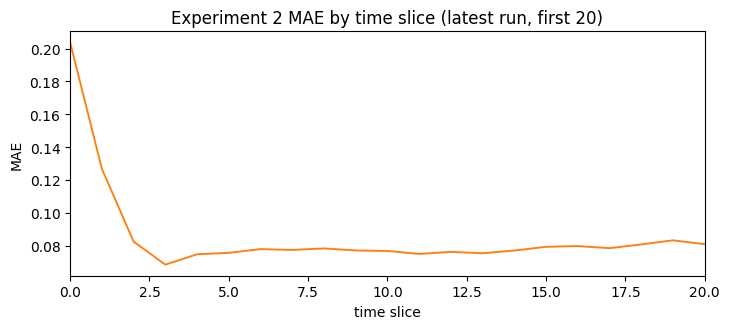

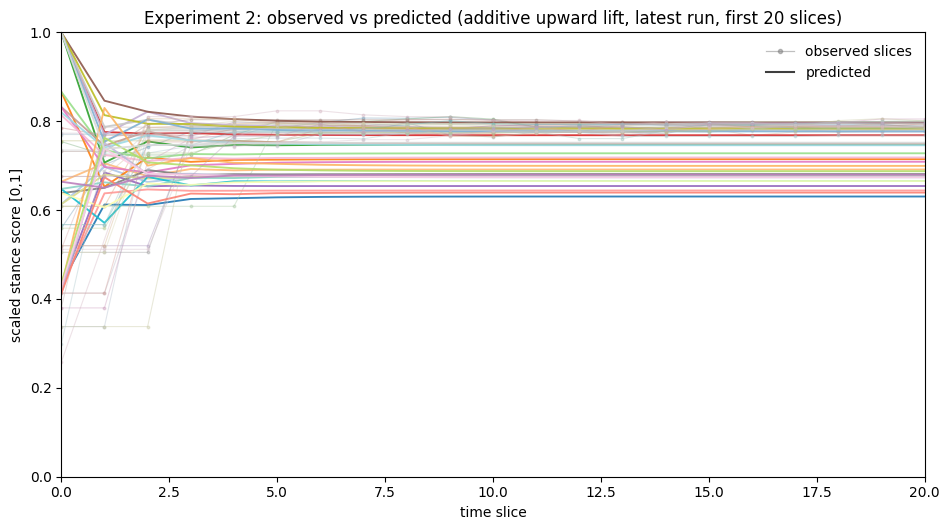

,experiment,window_slices,lambda_or_lambda_social,bias_lift,rmse_3run_window,mae_3run_window,latest_rmse_window,latest_mae_window
0,agent_specific_bias_vector,20,0.2,NaN,0.109289,0.086128,0.092255,0.075968
1,constant_global_upward_lift,20,0.8,0.35,0.127743,0.090545,0.109923,0.085963


In [24]:
rows2 = []
for lam in PARAMS['lambda_grid']:
    for delta in PARAMS['bias_lift_grid']:
        run_metrics = []
        for run_name, data in RUN_DATA.items():
            assigned_init, profile_init, init_post, base_x0 = initial_signals(data)
            out = run_fj_with_global_bias_lift(
                data,
                lam_social=lam,
                bias_lift=delta,
                base_x0_unit_dict=base_x0,
            )
            m = evaluate_records(out['records'], horizon=PARAMS['exp2_eval_horizon'])
            run_metrics.append(m)

        n_total = int(sum(m['n_eval'] for m in run_metrics))
        if n_total == 0:
            continue
        w_rmse = float(np.sqrt(np.sum([(m['rmse'] ** 2) * m['n_eval'] for m in run_metrics]) / n_total))
        w_mae = float(np.sum([m['mae'] * m['n_eval'] for m in run_metrics]) / n_total)
        rows2.append(
            {
                'lambda_social': float(lam),
                'bias_lift': float(delta),
                'rmse': w_rmse,
                'mae': w_mae,
                'n_eval': n_total,
            }
        )

exp2_res = pd.DataFrame(rows2).sort_values(['rmse', 'mae']).reset_index(drop=True)
display(exp2_res.head(10))
best2 = exp2_res.iloc[0].to_dict()
print('Best Experiment-2 params:', best2)

assigned_latest, profile_latest, init_latest, base_latest = initial_signals(latest_data)
exp2_latest_out = run_fj_with_global_bias_lift(
    latest_data,
    lam_social=best2['lambda_social'],
    bias_lift=best2['bias_lift'],
    base_x0_unit_dict=base_latest,
)
exp2_latest_df = pd.DataFrame(exp2_latest_out['records']).sort_values(['agent', 'time_slice']).reset_index(drop=True)
exp2_latest_metrics = evaluate_records(exp2_latest_out['records'], horizon=PARAMS['exp2_eval_horizon'])
print(f"Experiment 2 latest-run metrics (first {PARAMS['exp2_eval_horizon']} slices):", exp2_latest_metrics)

err2_df = exp2_latest_df[(exp2_latest_df['has_obs']) & (exp2_latest_df['time_slice'] <= PARAMS['exp2_plot_horizon'])].copy()
err2_df['abs_err'] = (err2_df['pred_unit'] - err2_df['obs_unit']).abs()
err2_t = err2_df.groupby('time_slice', as_index=False)['abs_err'].mean().rename(columns={'abs_err': 'mae'})

plt.figure(figsize=(7.4, 3.4))
plt.plot(err2_t['time_slice'], err2_t['mae'], color='tab:orange', linewidth=1.35)
plt.title(f"Experiment 2 MAE by time slice (latest run, first {PARAMS['exp2_plot_horizon']})")
plt.xlabel('time slice')
plt.ylabel('MAE')
plt.xlim(0, PARAMS['exp2_plot_horizon'])
plt.tight_layout()
plt.show()

plot_all_agents(
    exp2_latest_df,
    title=f"Experiment 2: observed vs predicted (additive upward lift, latest run, first {PARAMS['exp2_plot_horizon']} slices)",
    horizon=PARAMS['exp2_plot_horizon'],
)

comparison = pd.DataFrame(
    [
        {
            'experiment': 'agent_specific_bias_vector',
            'window_slices': PARAMS['exp1_eval_horizon'],
            'lambda_or_lambda_social': best1['lambda'],
            'bias_lift': np.nan,
            'rmse_3run_window': best1['rmse'],
            'mae_3run_window': best1['mae'],
            'latest_rmse_window': exp1_latest_metrics['rmse'],
            'latest_mae_window': exp1_latest_metrics['mae'],
        },
        {
            'experiment': 'constant_global_upward_lift',
            'window_slices': PARAMS['exp2_eval_horizon'],
            'lambda_or_lambda_social': best2['lambda_social'],
            'bias_lift': best2['bias_lift'],
            'rmse_3run_window': best2['rmse'],
            'mae_3run_window': best2['mae'],
            'latest_rmse_window': exp2_latest_metrics['rmse'],
            'latest_mae_window': exp2_latest_metrics['mae'],
        },
    ]
)
display(comparison)